In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
!unzip /content/drive/MyDrive/project-cv2/archive.zip -d /content/dataset

Archive:  /content/drive/MyDrive/project-cv2/archive.zip
replace /content/dataset/images/0_2000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/dataset/images/10000_2004.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [8]:
import os
import cv2
import torch
from torch.utils.data import Dataset
import numpy as np

#setting up dataset
class MangaDataset(Dataset):

    def __init__(self, color_dir, size=256):

        self.color_dir = color_dir
        self.size = size

        # keep only image files
        self.images = [f for f in os.listdir(color_dir)
                       if f.endswith((".jpg", ".png", ".jpeg"))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.color_dir, self.images[idx])

        color = cv2.imread(img_path)

        if color is None:
            raise ValueError(f"Image not found: {img_path}")

        color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)

        # grayscale input
        gray = cv2.cvtColor(color, cv2.COLOR_RGB2GRAY)

        # resize
        color = cv2.resize(color, (self.size, self.size))
        gray = cv2.resize(gray, (self.size, self.size))

        # EDGE MAP (manga-style input)
        edges = cv2.Canny(gray, 50, 150)

        # normalize
        color = color.astype(np.float32) / 255.0
        edges = edges.astype(np.float32) / 255.0

        # add channel
        edges = np.expand_dims(edges, axis=0)

        # convert to tensor
        gray = torch.from_numpy(gray)
        color = torch.from_numpy(color).permute(2,0,1)

        return edges, color

dataset = MangaDataset("/content/dataset/images")

print(len(dataset))
gray, color = dataset[0]

print(gray.shape)
print(color.shape)

63565
(1, 256, 256)
torch.Size([3, 256, 256])


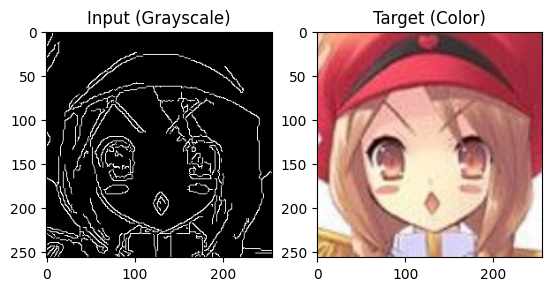

In [9]:
import matplotlib.pyplot as plt

#checking if dataset is set up correctly
plt.subplot(1,2,1)
plt.title("Input (Grayscale)")
plt.imshow(gray.squeeze(), cmap='gray')

plt.subplot(1,2,2)
plt.title("Target (Color)")
plt.imshow(color.permute(1,2,0))

plt.show()

In [10]:
from torch.utils.data import DataLoader

#Dataloader
dataset = MangaDataset("/content/dataset/images", size=256)

train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)
#checking dataloader
gray, color = next(iter(train_loader))

print(gray.shape)
print(color.shape)

torch.Size([8, 1, 256, 256])
torch.Size([8, 3, 256, 256])


In [12]:
#Unet
import torch
import torch.nn as nn

class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # ==============================
        # Encoder (Feature Extraction)
        # ==============================

        # First encoder block
        # Input: 1 channel grayscale image
        # Output: 64 feature maps
        self.encoder1 = nn.Sequential(
            nn.Conv2d(1,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU()
        )

        # Max pooling reduces spatial size (256 -> 128)
        self.pool = nn.MaxPool2d(2)

        # Second encoder block
        # Output: 128 feature maps
        self.encoder2 = nn.Sequential(
            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),
            nn.ReLU()
        )

        # Third encoder block
        # Output: 256 feature maps
        self.encoder3 = nn.Sequential(
            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU()
        )

        # ==============================
        # Bottleneck (Deepest Features)
        # ==============================

        # This layer learns high-level structure
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256,512,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU()
        )

        # ==============================
        # Decoder (Upsampling)
        # ==============================

        # Transposed convolution increases image size
        # 64x64 -> 128x128
        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)

        # Decoder block
        self.decoder3 = nn.Sequential(
            nn.Conv2d(512,256,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU()
        )

        # 128x128 -> 256x256
        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)

        self.decoder2 = nn.Sequential(
            nn.Conv2d(256,128,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),
            nn.ReLU()
        )

        # Final upsampling
        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)

        # Final decoder block
        # Produces 3 output channels (RGB)
        self.decoder1 = nn.Sequential(
            nn.Conv2d(128,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,3,1)
        )

    # ==============================
    # Forward Pass
    # ==============================
    def forward(self,x):

        # Encoder path
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder path with skip connections
        u3 = self.up3(b)
        c3 = torch.cat([u3,e3],dim=1)
        d3 = self.decoder3(c3)

        u2 = self.up2(d3)
        c2 = torch.cat([u2,e2],dim=1)
        d2 = self.decoder2(c2)

        u1 = self.up1(d2)
        c1 = torch.cat([u1,e1],dim=1)

        # Final output layer
        out = self.decoder1(c1)

        # Sigmoid keeps pixel values between 0 and 1
        return torch.sigmoid(out)



# ==============================
# Setup Training
# ==============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

criterion = nn.L1Loss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# ==============================
# Training Loop
# ==============================

epochs = 30

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for gray, color in train_loader:

        gray = gray.to(device)
        color = color.to(device)

        pred = model(gray)

        loss = criterion(pred, color)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        total_loss += loss.item() * gray.size(0)

    avg_loss = total_loss / len(train_loader.dataset)

    print("Epoch:", epoch+1, "Loss:", avg_loss)

    scheduler.step()

    # Save checkpoint every 2 epochs
    if (epoch + 1) % 2 == 0:
        torch.save(model.state_dict(), "/content/drive/MyDrive/project-cv2/model_epoch_"+str(epoch+1)+".pth")

# ==============================
# Save Final Model
# ==============================

torch.save(model.state_dict(), "/content/drive/MyDrive/project-cv2/manga_colorizer.pth")

Epoch: 1 Loss: 0.1597659449052972
Epoch: 2 Loss: 0.1321301243836505
Epoch: 3 Loss: 0.12280665618973113
Epoch: 4 Loss: 0.11661700604423854
Epoch: 5 Loss: 0.11157871427685949
Epoch: 6 Loss: 0.10739382625981131
Epoch: 7 Loss: 0.10365652385704975
Epoch: 8 Loss: 0.10029619126869656
Epoch: 9 Loss: 0.09734220739723912
Epoch: 10 Loss: 0.09471259458236819
Epoch: 11 Loss: 0.08934354732183902
Epoch: 12 Loss: 0.08710479656307495
Epoch: 13 Loss: 0.08541851935274228
Epoch: 14 Loss: 0.08396555498778037
Epoch: 15 Loss: 0.08268266911305236
Epoch: 16 Loss: 0.08155331673392302
Epoch: 17 Loss: 0.08049662446587502
Epoch: 18 Loss: 0.07952571011300842
Epoch: 19 Loss: 0.07862848303312492
Epoch: 20 Loss: 0.07779114231236339
Epoch: 21 Loss: 0.07516221702555974
Epoch: 22 Loss: 0.07424860765436214
Epoch: 23 Loss: 0.07357760494936649
Epoch: 24 Loss: 0.07299244610225995
Epoch: 25 Loss: 0.07243767847909716
Epoch: 26 Loss: 0.07191053686496042
Epoch: 27 Loss: 0.07141230578249261
Epoch: 28 Loss: 0.07093769917070449
Epo

In [13]:
model = UNet().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/project-cv2/manga_colorizer.pth",map_location=device))
model.eval()

UNet(
  (encoder1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (encoder3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (bottleneck): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (up3): ConvTranspose2d(512, 256, kernel_size=(2

Model loaded successfully


/tmp/ipykernel_7643/1830433456.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(edges).float().unsqueeze(0).to(device)


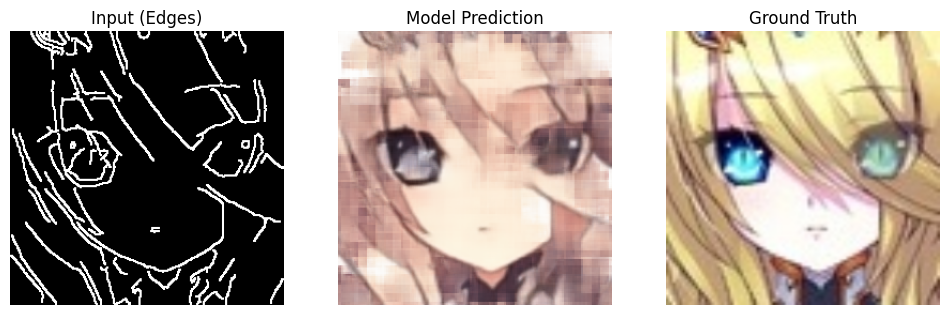

In [44]:
# ==============================
# Full Colorization Demo Code (FIXED)
# ==============================

import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ==============================
# Device Setup
# ==============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# Load Trained Model
# ==============================

model = UNet().to(device)

model.load_state_dict(torch.load("/content/drive/MyDrive/project-cv2/manga_colorizer_finetuned.pth", map_location=device))

model.eval()

print("Model loaded successfully")

# ==============================
# Select Image From Dataset
# ==============================

index = 100 % len(dataset)

edges, color = dataset[index]

# convert tensors to device
input_tensor = torch.tensor(edges).float().unsqueeze(0).to(device)

# ==============================
# Run Model Prediction
# ==============================

with torch.no_grad():
    pred = model(input_tensor)

# ==============================
# Convert Outputs
# ==============================

pred = pred.squeeze().cpu().numpy()
pred = np.transpose(pred, (1,2,0))
pred = np.clip(pred, 0, 1)

color_gt = color.permute(1,2,0).cpu().numpy()
edge_img = edges.squeeze()

# ==============================
# Display Results
# ==============================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input (Edges)")
plt.imshow(edge_img, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Model Prediction")
plt.imshow(pred)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Ground Truth")
plt.imshow(color_gt)
plt.axis("off")

plt.show()

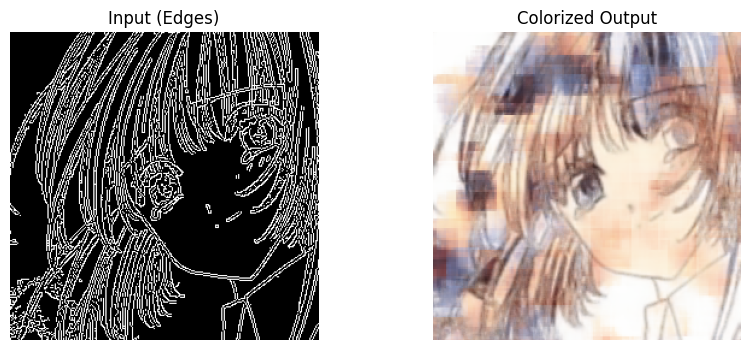

In [63]:
# ==============================
# Load Libraries
# ==============================

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Load Model
# ==============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/project-cv2/manga_colorizer.pth",
               map_location=device)
)

model.eval()

# ==============================
# Load External Image
# ==============================

img_path = "/content/drive/MyDrive/project-cv2/manga/test1.jpg"

img = cv2.imread(img_path)

if img is None:
    raise ValueError("Image not found")

# resize FIRST (important)
img = cv2.resize(img, (256,256))

# convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==============================
# EDGE INPUT (MATCH TRAINING)
# ==============================

edges = cv2.Canny(gray, 50, 150)
edges = edges.astype(np.float32) / 255.0

# ==============================
# Convert to Tensor (FIXED)
# ==============================

input_tensor = torch.tensor(edges).unsqueeze(0).unsqueeze(0).to(device)
# shape: (1, 1, 256, 256)

# ==============================
# Run Model
# ==============================

with torch.no_grad():
    pred = model(input_tensor)

# ==============================
# Convert Output
# ==============================

pred = pred.squeeze().cpu().numpy()
pred = np.transpose(pred, (1,2,0))
pred = np.clip(pred, 0, 1)

# ==============================
# Display Results
# ==============================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Input (Edges)")   # 🔥 correct label
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Colorized Output")
plt.imshow(pred)
plt.axis("off")

plt.show()

In [28]:
#Fine-Tuning
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset

class MangaDataset(Dataset):
    def __init__(self, folder, size=256):
        self.folder = folder
        self.size = size
        self.images = [f for f in os.listdir(folder)
                       if f.endswith((".jpg",".png",".jpeg"))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = os.path.join(self.folder, self.images[idx])
        img = cv2.imread(path)

        img = cv2.resize(img, (self.size, self.size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # AUGMENTATION
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 1)

        # BETTER EDGES
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        blur = cv2.GaussianBlur(gray, (5,5), 0)

        edges = cv2.Canny(blur, 100, 200)
        edges = cv2.dilate(edges, np.ones((2,2), np.uint8), iterations=1)

        # normalize
        edges = edges.astype(np.float32) / 255.0
        img = img.astype(np.float32) / 255.0

        edges = torch.from_numpy(edges).unsqueeze(0)
        color = torch.from_numpy(img).permute(2,0,1)

        return edges, color


In [29]:
from torch.utils.data import DataLoader

dataset = MangaDataset("/content/dataset/images")

train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/project-cv2/manga_colorizer.pth",
               map_location=device)
)

print("Loaded model for fine-tuning")


Loaded model for fine-tuning


In [32]:
l1 = torch.nn.L1Loss()
l2 = torch.nn.MSELoss()

def loss_fn(pred, target):
    return l1(pred, target) + 0.3 * l2(pred, target)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
import torchvision.utils as vutils

epochs = 10

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for edges, color in train_loader:

        edges = edges.to(device)
        color = color.to(device)

        pred = model(edges)

        loss = loss_fn(pred, color)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item() * edges.size(0)

    avg_loss = total_loss / len(train_loader.dataset)

    print(f"[Fine-tune] Epoch {epoch+1} | Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "/content/drive/MyDrive/project-cv2/manga_colorizer_finetuned.pth")

[Fine-tune] Epoch 1 | Loss: 0.1403
[Fine-tune] Epoch 2 | Loss: 0.1379
[Fine-tune] Epoch 3 | Loss: 0.1361
[Fine-tune] Epoch 4 | Loss: 0.1346
[Fine-tune] Epoch 5 | Loss: 0.1334
[Fine-tune] Epoch 6 | Loss: 0.1323
[Fine-tune] Epoch 7 | Loss: 0.1312
[Fine-tune] Epoch 8 | Loss: 0.1303
[Fine-tune] Epoch 9 | Loss: 0.1293
[Fine-tune] Epoch 10 | Loss: 0.1285
